<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Vanila_Auto_Encoders_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#programar um autoencoder básico
#Implementando bibliotecas
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
#definição do dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.8 MB/s eta 0:00:00


In [18]:
#transformação de imagem
import matplotlib.pyplot as plt
img_transform = transforms.Compose([
    transforms.ToTensor(), #conversão de imagem em um tensor
    transforms.Normalize([0.5], [0.5]), #normalização
    transforms.Lambda(lambda x: x.to(device)) #transferência para o dispositivo
])

In [7]:
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.25MB/s]


In [8]:
batch_size = 526
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [9]:
#modelo autoencoder
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim): #dimesão latente como parâmetro
        super().__init__()
        self.latent_dim = latent_dim
        #codificador
        self.encoder = nn.Sequential(
            nn.Linear(28*28,128), nn.ReLU(True), #coprime a imagem de entrada
            nn.Linear(128,64), nn.ReLU(True),
            nn.Linear(64,latent_dim))
        #decodificador
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,64),nn.ReLU(True),
            nn.Linear(64,128),nn.ReLU(True),
            nn.Linear(128,28*28),nn.Tanh()) #reconstroi a imagem a parit da representação latente

    def forward(self,x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [10]:
#funções para treinar e validar o modleo
def train_batch(input, model, optimizer, criterion):
    model.train()
    input = input.to(device)
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input) #perda do erro quadrático médio
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    input = input.to(device)
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  val_loss: 0.222  trn_loss: 0.321  (17.12s - 68.48s remaining)
EPOCH: 2.000  val_loss: 0.189  trn_loss: 0.204  (34.43s - 51.65s remaining)
EPOCH: 3.000  val_loss: 0.173  trn_loss: 0.179  (51.94s - 34.63s remaining)
EPOCH: 4.000  val_loss: 0.161  trn_loss: 0.166  (69.91s - 17.48s remaining)
EPOCH: 5.000  val_loss: 0.156  trn_loss: 0.158  (86.96s - 0.00s remaining)


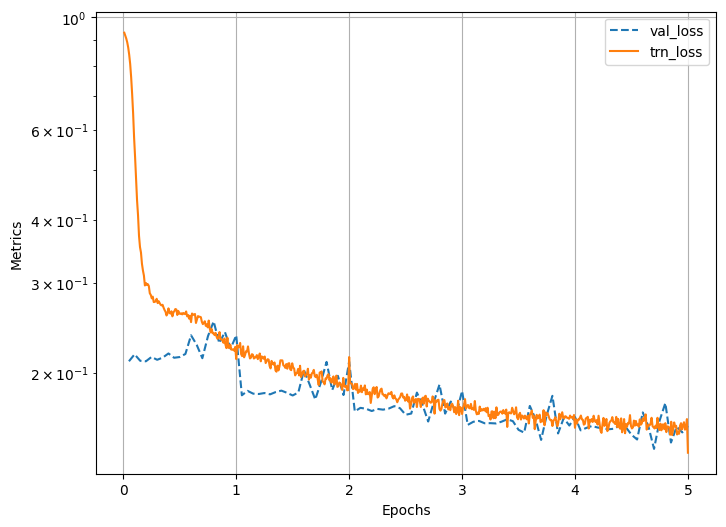

In [15]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
#treinamento do autoencoder por 5 épocas
num_epochs = 5
log = Report(num_epochs)
#definimos as perdas de treinamento e validação
for epoch in range(num_epochs):
  N = len(trn_dl)
  for ix, (data, _) in enumerate(trn_dl):
    loss = train_batch(data, model, optimizer, criterion)
    log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

  N = len(val_dl)
  for ix, (data, _) in enumerate(val_dl):
    loss = validate_batch(data, model, criterion)
    log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
  log.report_avgs(epoch+1)
log.plot(log=True)

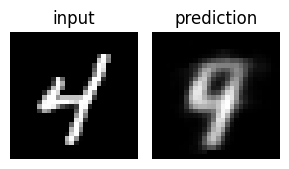

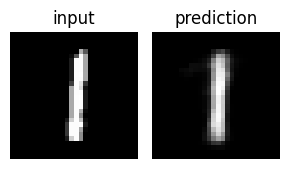

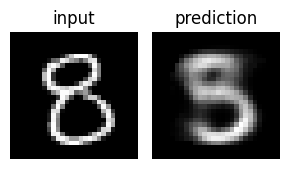

In [20]:
#testando o autoencoder em algumas imagens
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  val_loss: 0.209  trn_loss: 0.306  (18.95s - 75.79s remaining)
EPOCH: 1.000  val_loss: 0.209  trn_loss: 0.306  (35.97s - 143.87s remaining)
EPOCH: 1.000  val_loss: 0.209  trn_loss: 0.306  (54.76s - 219.03s remaining)
EPOCH: 1.000  val_loss: 0.209  trn_loss: 0.306  (71.98s - 287.92s remaining)
EPOCH: 1.000  val_loss: 0.209  trn_loss: 0.306  (89.40s - 357.62s remaining)


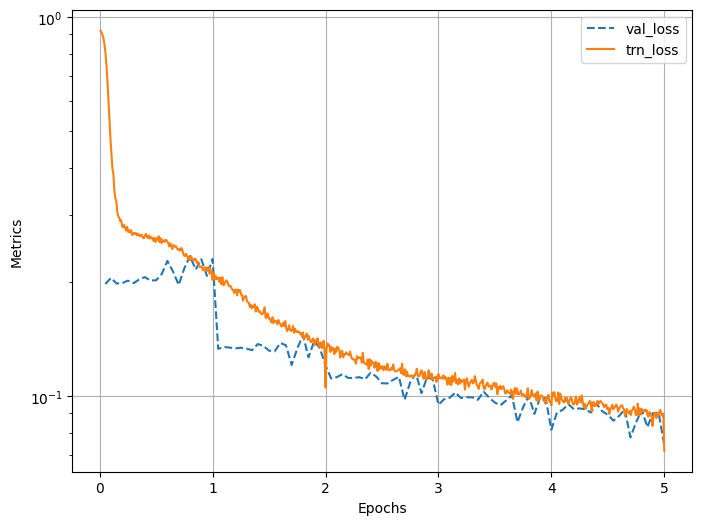

EPOCH: 1.000  val_loss: 0.235  trn_loss: 0.310  (18.18s - 72.72s remaining)
EPOCH: 1.000  val_loss: 0.235  trn_loss: 0.310  (35.69s - 142.74s remaining)
EPOCH: 1.000  val_loss: 0.235  trn_loss: 0.310  (53.86s - 215.44s remaining)
EPOCH: 1.000  val_loss: 0.235  trn_loss: 0.310  (72.79s - 291.16s remaining)
EPOCH: 1.000  val_loss: 0.235  trn_loss: 0.310  (94.50s - 377.99s remaining)


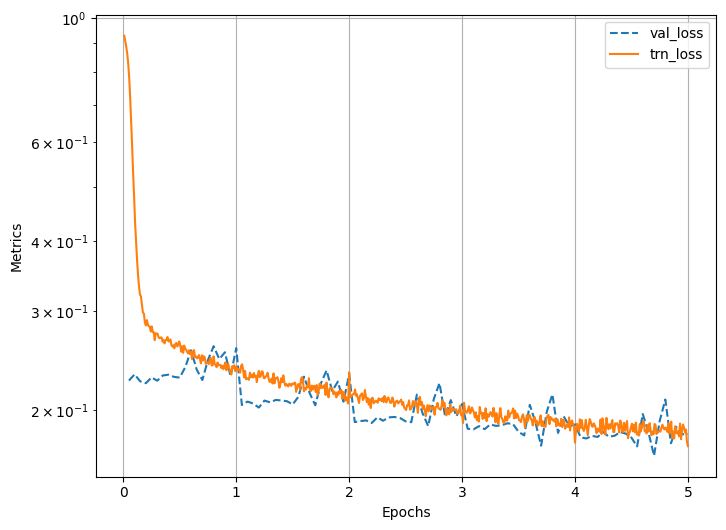

EPOCH: 1.000  val_loss: 0.231  trn_loss: 0.317  (17.48s - 69.92s remaining)
EPOCH: 1.000  val_loss: 0.231  trn_loss: 0.317  (35.78s - 143.13s remaining)
EPOCH: 1.000  val_loss: 0.231  trn_loss: 0.317  (53.14s - 212.57s remaining)
EPOCH: 1.000  val_loss: 0.231  trn_loss: 0.317  (70.67s - 282.70s remaining)
EPOCH: 1.000  val_loss: 0.231  trn_loss: 0.317  (101.47s - 405.86s remaining)


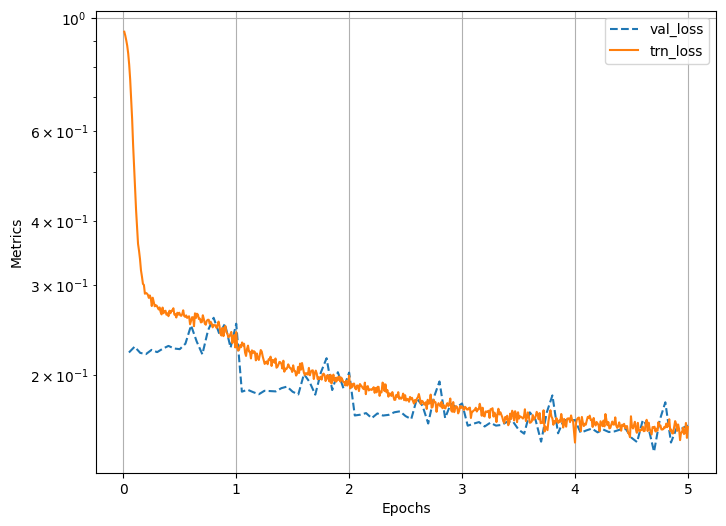

EPOCH: 1.000  val_loss: 0.197  trn_loss: 0.298  (37.04s - 148.16s remaining)
EPOCH: 1.000  val_loss: 0.197  trn_loss: 0.298  (76.38s - 305.52s remaining)
EPOCH: 1.000  val_loss: 0.197  trn_loss: 0.298  (107.55s - 430.22s remaining)
EPOCH: 1.000  val_loss: 0.197  trn_loss: 0.298  (134.47s - 537.87s remaining)
EPOCH: 1.000  val_loss: 0.197  trn_loss: 0.298  (165.04s - 660.14s remaining)


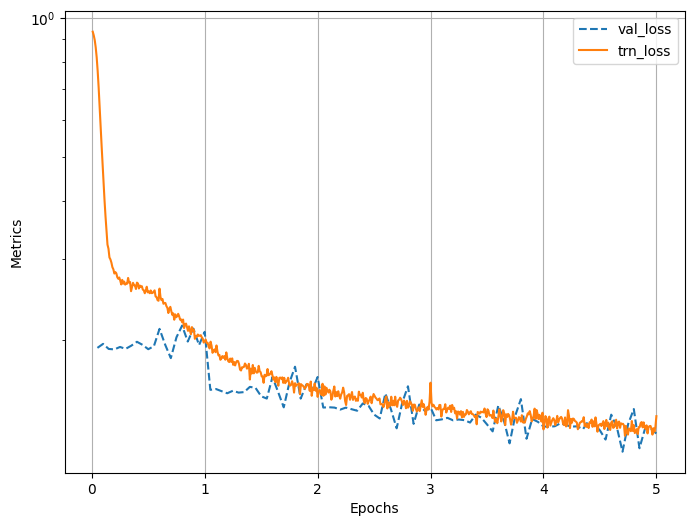

EPOCH: 1.000  val_loss: 0.206  trn_loss: 0.303  (30.45s - 121.82s remaining)
EPOCH: 1.000  val_loss: 0.206  trn_loss: 0.303  (51.23s - 204.91s remaining)
EPOCH: 1.000  val_loss: 0.206  trn_loss: 0.303  (68.47s - 273.90s remaining)
EPOCH: 1.000  val_loss: 0.206  trn_loss: 0.303  (86.66s - 346.64s remaining)
EPOCH: 1.000  val_loss: 0.206  trn_loss: 0.303  (103.69s - 414.76s remaining)


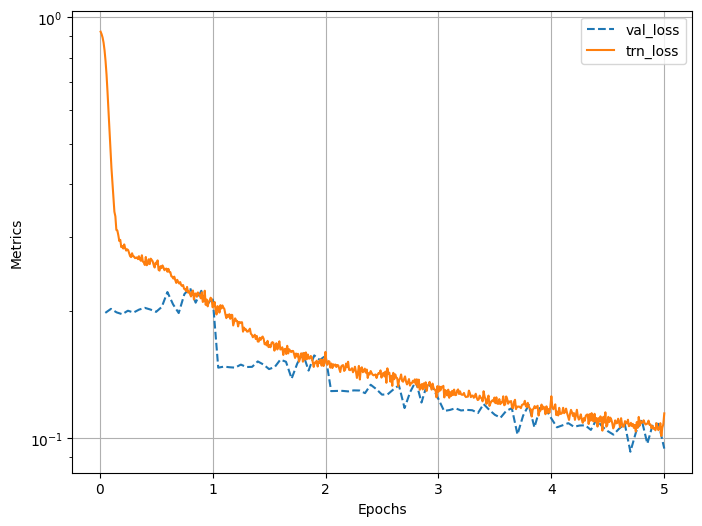

In [24]:
def train_aec(latent_dim):
  model = AutoEncoder(latent_dim).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

  num_epochs = 5
  log = Report(num_epochs)

  for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
      loss = train_batch(data, model, optimizer, criterion)
      log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
      loss = validate_batch(data, model, criterion)
      log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch=1)
  log.plot(log=True)
  return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

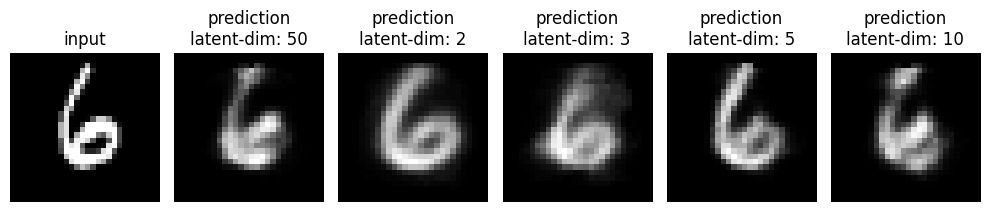

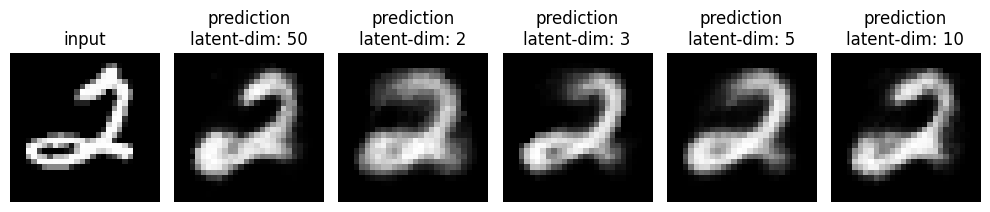

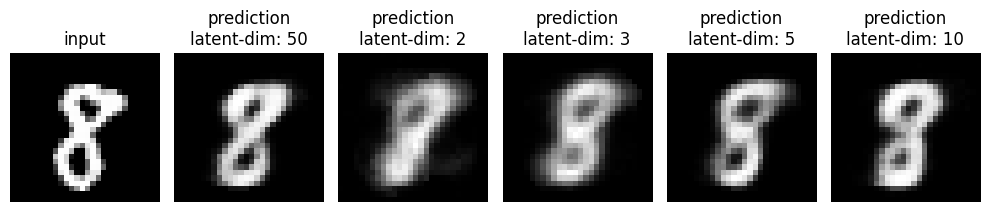

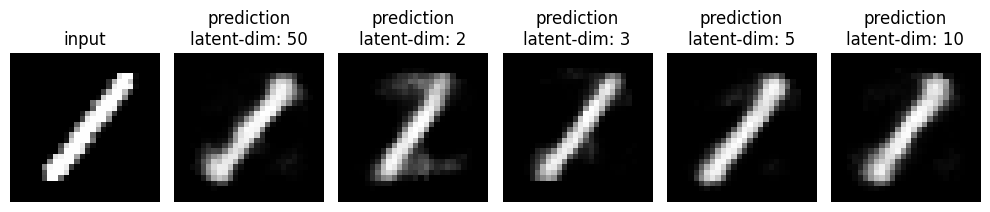

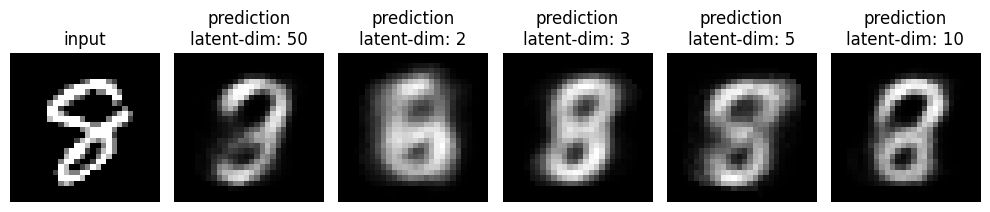

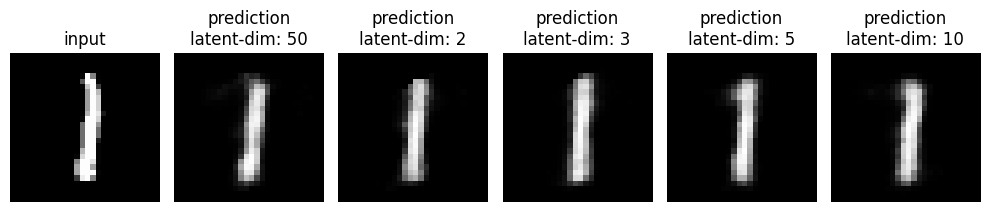

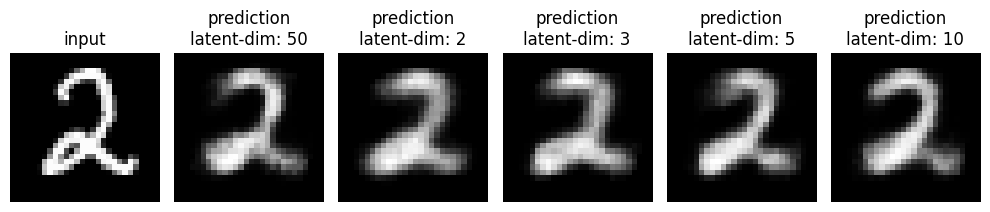

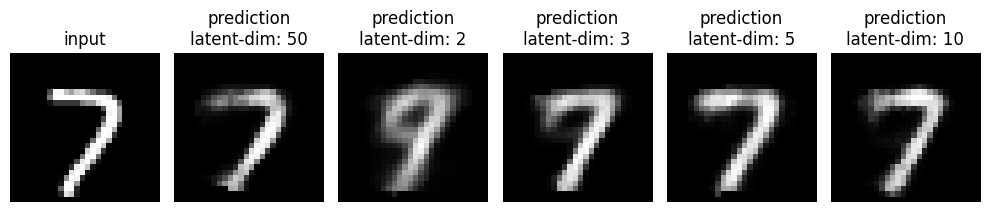

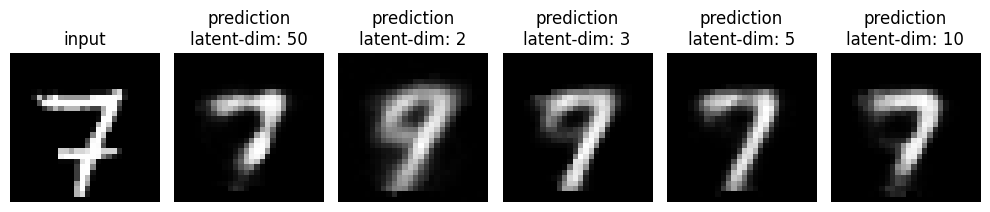

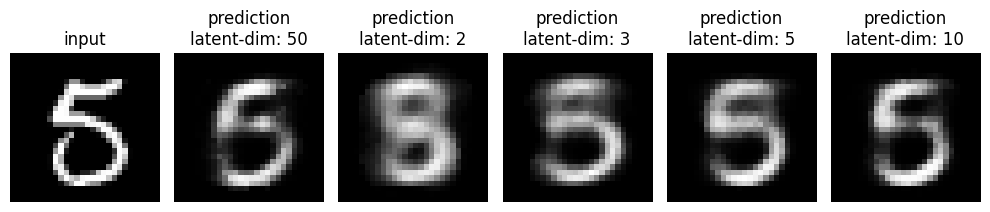

In [25]:
for _ in range(10):
  ix = np.random.randint(len(val_ds))
  im, _ = val_ds[ix]
  fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
  ax = iter(ax.flat)
  show(im[0], ax=next(ax), title='input')
  for model in aecs:
    _im = model(im[None])[0]
    show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim: {model.latent_dim}')
  plt.tight_layout()
  plt.show()